In [1]:
from collections.abc import Sequence
from json import load
import os
import sys

sys.path.append(os.path.abspath('../src'))

import joblib
from matplotlib.pyplot import imshow, ylabel, xlabel, yticks, xticks,\
                                plot, margins
import numpy as np
import polars as pl
from sklearn.base import BaseEstimator
from sklearn.metrics import f1_score, precision_score, recall_score,\
                            confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

from feature_extractor import FeatureExtractor


In [2]:
SEED = 42


In [3]:
dataset = pl.read_csv(
    '../data/processed/train.csv'
    ).drop('StimSite', 'Error_type_annot')


# Приготовления

## Разбиение на фолды

In [4]:
stratified_k_fold = StratifiedKFold(n_splits=5,
                                    random_state=SEED,
                                    shuffle=True)

feature_extractor = FeatureExtractor()

big_X_raw = dataset.drop('error_type_label')
big_y_raw = dataset['error_type_label']

folds_train = []
folds_val = []

for train_indices, val_indices in stratified_k_fold.split(
                                        np.zeros(dataset.height),
                                        big_y_raw):
    folds_train.append((
        feature_extractor.fit_transform(big_X_raw[train_indices]),
        big_y_raw[train_indices]
    ))
    folds_val.append((
        feature_extractor.transform(big_X_raw[val_indices]),
        big_y_raw[val_indices]
    ))


1462it [00:18, 77.30it/s]
702it [00:07, 88.07it/s]
1448it [00:17, 82.62it/s]
679it [00:07, 87.77it/s]
1450it [00:16, 88.70it/s]
698it [00:09, 74.71it/s] 
1444it [00:13, 106.27it/s]
697it [00:06, 106.79it/s]
1461it [00:13, 105.62it/s]
697it [00:06, 113.52it/s]


In [5]:
joblib.dump((folds_train, folds_val), 'features.joblib.xz', 9)


['features.joblib.xz']

## Функция для оценивания

In [6]:
error_type_ids_file = open('../data/processed/error_type_ids.json',
                        'r', -1, 'utf-8')
error_type_ids = load(error_type_ids_file)
error_type_ids_to_names: list[str] = [''] * 8
for k, v in error_type_ids.items():
    error_type_ids_to_names[v] = k


In [18]:
def evaluate(model: Pipeline, # BaseEstimator
    folds_train: list[tuple[pl.DataFrame, pl.Series]] = folds_train,
    folds_val: list[tuple[pl.DataFrame, pl.Series]] = folds_val,
    error_type_ids_to_names: list[str] = error_type_ids_to_names,
    *,
    include_classes: set[int] | None = None,
    merge_classes: list[int] | None = None,
    merge_classes_names: list[str] | None = None,
    supress_plot: bool = False,
    supress_print: bool = False):

    assert len(folds_train) == len(folds_val)
    number_of_folds: int = len(folds_train)
    classes_present: set[int] = {
                                   label 
                                   for _, y_val in folds_val 
                                   for label in y_val.unique().to_list()
                                }
    
    if include_classes:
        classes_present &= include_classes
    else:
        include_classes = classes_present

    if merge_classes:
        classes_present = {merge_classes[class_]
                           for class_ in classes_present}
        if merge_classes_names:
            error_type_ids_to_names = merge_classes_names
        else:
            error_type_ids_to_names = [f'Класс {i}'
                                for i
                                in range(len(error_type_ids_to_names))]
    else:
        merge_classes = [-1] * (max(classes_present) + 1)
        for class_ in classes_present:
            merge_classes[class_] = class_

    classes_present_names: list[str] = [error_type_ids_to_names[i]
                                        for i in classes_present]
    number_of_classes: int = len(classes_present)

    f1s = np.zeros((number_of_folds, number_of_classes))
    precisions = f1s.copy()
    recalls = f1s.copy()
    confusion_matrices = np.zeros((number_of_folds,
                                   number_of_classes, 
                                   number_of_classes))
    
    for i, (fold_train, fold_val)\
                            in enumerate(zip(folds_train, folds_val)):
        X_train, y_train = fold_train
        train_mask = y_train.is_in(include_classes)
        X_train, y_train = X_train.filter(train_mask),\
                                        y_train.filter(train_mask)
        y_train = pl.Series(merge_classes).gather(y_train)
        model.fit(X_train, y_train)

        X_val, y_val = fold_val
        val_mask = y_val.is_in(include_classes)
        X_val, y_val = X_val.filter(val_mask), y_val.filter(val_mask)
        y_val = pl.Series(merge_classes).gather(y_val)
        predictions = model.predict(X_val)

        precisions[i] = precision_score(y_val, predictions,
                                         average=None)
        recalls[i] = recall_score(y_val, predictions, average=None)
        f1s[i] = f1_score(y_val, predictions, average=None)
        confusion_matrices[i] = confusion_matrix(y_val, predictions,
                                                 normalize='true')
        
    np.set_printoptions(suppress=True)

    if not supress_print:
        print('Класс\t\t\tPrecision\tRecall\t\tF1')
        print(*('%s%.2f±%.2f\t%.2f±%.2f\t%.2f±%.2f' % (f'{name:<24}',
                precision_m.item(),
                precision_s.item(),
                recall_m.item(),
                recall_s.item(),
                f1_m.item(),
                f1_s.item())
                for name, precision_m, precision_s,
                        recall_m, recall_s, 
                        f1_m, f1_s
                in zip(classes_present_names,
                    precisions.mean(axis=0),
                    precisions.std(axis=0),
                    recalls.mean(axis=0),
                    recalls.std(axis=0),
                    f1s.mean(axis=0),
                    f1s.std(axis=0))), 
                sep='\n')
        print('%s%.2f±%.2f\t%.2f±%.2f\t%.2f±%.2f' % (f'{'По всем':<24}',
                precisions.mean(axis=1).mean(),
                precisions.std(axis=1).std(),
                recalls.mean(axis=1).mean(),
                recalls.std(axis=1).std(),
                f1s.mean(axis=1).mean(),
                f1s.mean(axis=1).std()))
    
    if not supress_plot:
        imshow(confusion_matrices.mean(axis=0))
        ylabel('Истина')
        xlabel('Предсказание')
        yticks(range(number_of_classes), classes_present_names)
        xticks(range(number_of_classes), classes_present_names, 
            rotation=45)

    return f1s.mean(axis=1).mean()


### Проверка функции для оценивания

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.98±0.00	0.96±0.00
speech arrest           0.89±0.09	0.80±0.22	0.82±0.14
аномия                  0.74±0.05	0.79±0.11	0.76±0.07
дизартрия               0.34±0.08	0.15±0.04	0.20±0.05
задержка                0.65±0.04	0.39±0.02	0.49±0.02
поиск слова             0.56±0.05	0.49±0.10	0.51±0.05
семантическая парафазия 0.46±0.12	0.22±0.06	0.30±0.08
фонетическая парафазия  0.61±0.04	0.41±0.07	0.49±0.05
По всем                 0.65±0.03	0.53±0.02	0.57±0.02


np.float64(0.5659873657340114)

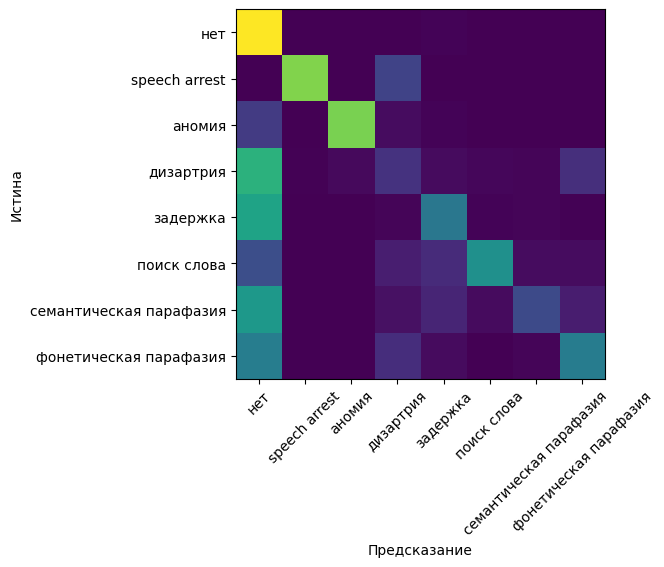

In [8]:
evaluate(DecisionTreeClassifier(max_depth=10))


Класс			Precision	Recall		F1
нет                     0.97±0.00	0.99±0.00	0.98±0.00
задержка                0.67±0.01	0.43±0.04	0.53±0.03
По всем                 0.82±0.01	0.71±0.02	0.75±0.02


np.float64(0.7516090203699491)

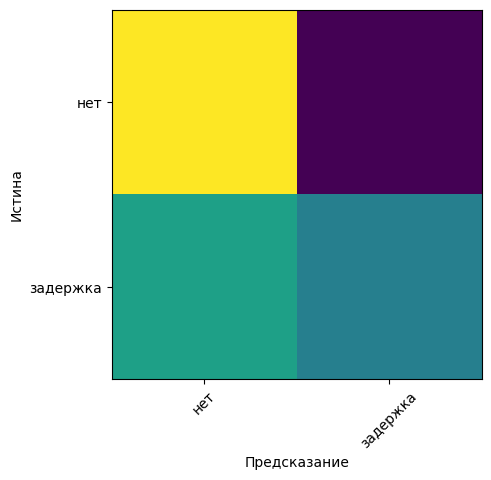

In [16]:
evaluate(DecisionTreeClassifier(max_depth=10), include_classes={0,4})


Класс			Precision	Recall		F1
нет                     0.94±0.00	0.98±0.00	0.96±0.00
есть                    0.77±0.03	0.50±0.03	0.61±0.02
По всем                 0.86±0.01	0.74±0.02	0.78±0.01


np.float64(0.784820707513585)

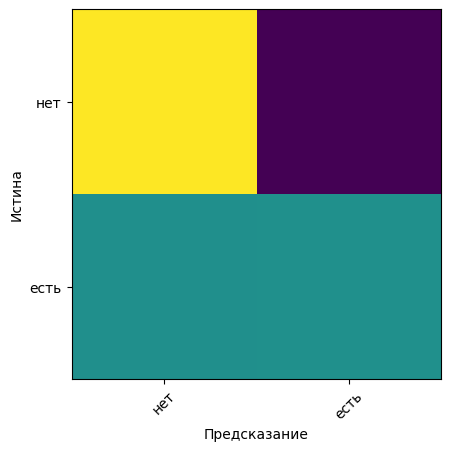

In [12]:
evaluate(DecisionTreeClassifier(max_depth=10, random_state=SEED),
         merge_classes=[0,1,1,1,1,1,1,1],
         merge_classes_names=['нет', 'есть'])


Класс			Precision	Recall		F1
Класс 0                 0.94±0.00	0.98±0.00	0.96±0.00
Класс 1                 0.77±0.03	0.50±0.03	0.61±0.02
По всем                 0.86±0.01	0.74±0.02	0.78±0.01


np.float64(0.784820707513585)

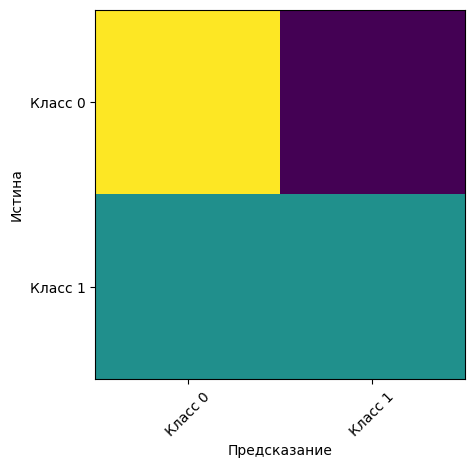

In [13]:
evaluate(DecisionTreeClassifier(max_depth=10, random_state=SEED),
         merge_classes=[0,1,1,1,1,1,1,1])

# Бейзлайн

Просто решающее дерево с подобранной глубиной не больше 13 ($2^{13} = 8192$, в обучающих фолдах около 14 000 примеров; дерево, строго говоря, не сможет их заучить чисто созданием листов, придётся что-то обобщать).

In [ ]:
best_macro_F1 = 0.0
best_max_depth = 0
for max_depth in range(1, 13+1):
    score = evaluate(DecisionTreeClassifier(max_depth=max_depth, 
                                            random_state=SEED),
                                            supress_plot=True,
                                            supress_print=True)
    if score > best_macro_F1:
        best_macro_F1 = score
        best_max_depth = max_depth


In [ ]:
best_max_depth


10

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.99±0.00	0.96±0.00
speech arrest           0.89±0.09	0.80±0.22	0.82±0.14
аномия                  0.75±0.03	0.76±0.13	0.75±0.07
дизартрия               0.39±0.08	0.16±0.02	0.23±0.04
задержка                0.65±0.03	0.39±0.01	0.49±0.01
поиск слова             0.61±0.09	0.51±0.09	0.54±0.05
семантическая парафазия 0.44±0.06	0.22±0.05	0.29±0.05
фонетическая парафазия  0.61±0.04	0.41±0.07	0.49±0.05
По всем                 0.66±0.02	0.53±0.02	0.57±0.03


np.float64(0.5720462677469886)

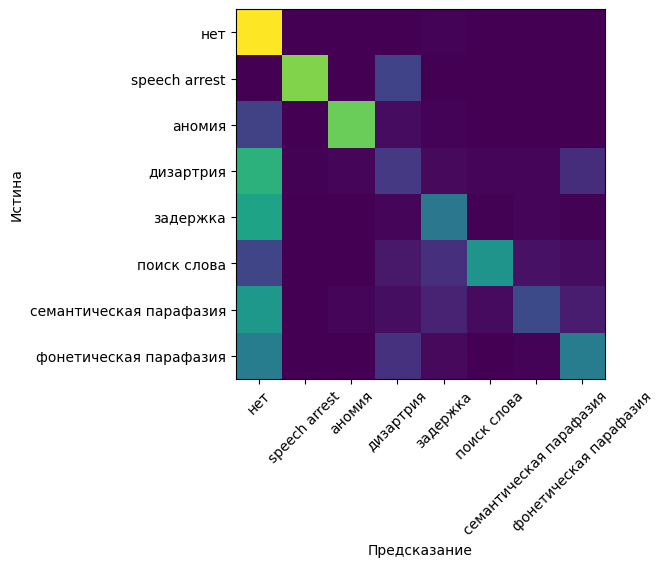

In [23]:
evaluate(DecisionTreeClassifier(max_depth=10, 
                                random_state=SEED))


# Простые подходы